# Trendline Detection Research Notebook

This notebook was created as an experimental sandbox for developing and
testing support/resistance trendline logic before integrating it into the
real-time websocket trading engine.

The objective of this notebook is to:

- experiment with trendline generation,
- study market structure behavior,
- validate support/resistance logic,
- test trendline invalidation rules,
- and prototype visualization techniques.

Unlike the main real-time engine, this notebook works on static historical
candlestick data and is primarily intended for research and development.

---

# Why This Notebook Exists

Building real-time trading systems directly is difficult because:

- market data changes continuously,
- debugging live systems is harder,
- and visualization becomes complicated.

Therefore, this notebook acts as a controlled environment where:

- ideas can be tested safely,
- trendline logic can be refined,
- and support/resistance behavior can be studied visually.

Once the logic becomes stable, it can then be transferred into the
real-time websocket engine.

---

# Main Research Goals

This notebook explores:

- swing high and swing low detection,
- trendline generation,
- support/resistance zone creation,
- active trendline validation,
- breakout invalidation,
- and market structure persistence.

---

# Important Difference from the Main Engine

Notebook:
- static historical analysis
- research-oriented
- visualization-focused

Main Engine:
- live websocket streaming
- real-time candle updates
- event-driven processing
- production-style architecture

## Loading Historical Bitcoin Market Data

We begin with historical 1-minute Bitcoin candlestick data.

Each row represents one candle containing:

 - Open price
 - High price
 - Low price
 - Close price
 - Volume

Candlestick data is the foundation of most technical analysis systems.

The trendline engine will later use:

 - LOW prices for support detection
 - HIGH prices for resistance detection

 because support forms near market bottoms while resistance forms near market tops.

In [1]:
import pandas as pd

df = pd.read_csv('btcusd_bitstamp_1min_latest.csv')

# Convert Unix timestamp (seconds)
df['date'] = pd.to_datetime(df['timestamp'], unit='s', utc=True)

# Convert to IST
df['date'] = df['date'].dt.tz_convert('Asia/Kolkata')

# Set index
df.set_index('date', inplace=True)

# Optional: remove old timestamp column
df.drop(columns=['timestamp'], inplace=True)

df

,open,high,low,close,volume
date,,,,,
2025-12-20 10:50:00+05:30,88346,88357,88345,88357,1.134390
2025-12-20 10:51:00+05:30,88368,88441,88368,88420,4.195394
2025-12-20 10:52:00+05:30,88377,88377,88343,88343,0.115077
2025-12-20 10:53:00+05:30,88329,88329,88316,88318,0.042470
2025-12-20 10:54:00+05:30,88318,88372,88318,88372,0.032629
...,...,...,...,...,...
2026-05-12 06:51:00+05:30,81316,81316,81268,81277,0.071748
2026-05-12 06:52:00+05:30,81277,81288,81243,81269,0.388875
2026-05-12 06:53:00+05:30,81263,81295,81241,81295,5.270299


## Support & Resistance Detection

The `trendln` library works in multiple stages:

### Step 1:
Detect local minima and maxima (swing lows and swing highs).

### Step 2:
Generate possible trendlines connecting these points.

### Step 3:
Rank trendlines mathematically using regression quality.

### Step 4:
Return the best candidate support and resistance structures.

We use:

- LOW prices  -> support detection
- HIGH prices -> resistance detection

because:

- buyers usually defend lows
- sellers usually defend highs

This mimics how traders manually draw trendlines.

In [2]:
# ============================================================
# Imports
# ============================================================
import trendln
df = df.tail(100)
# ============================================================
# Calculating Support and Resistance Levels
# ============================================================
(minimaIdxs, pmin, mintrend, minwindows),(maximaIdxs, pmax, maxtrend, maxwindows) = trendln.calc_support_resistance(
    (df['low'].to_numpy(), df['high'].to_numpy()),
    extmethod=trendln.METHOD_NUMDIFF,
    method=trendln.METHOD_NSQUREDLOGN,
    window=50,
    errpct=0.003)

The library divides data into windows before searching for trendlines.

Smaller window:
 - captures local market structure
 - reacts faster
 - more sensitive to noise

Larger window:
 - captures long-term structure
 - more stable
 - slower to react

Here: `window=50` means trendlines are generated using rolling groups of 50 candles.

In [3]:
print(minwindows)

[[], [([50, 58, 90], (np.float64(-6.678571428571429), np.float64(81853.11904761904), np.float64(0.09523809524086703), np.float64(0.010309826235679059), np.float64(0.7033891069970188), np.float64(0.005807200928712718))), ([4, 27, 90], (np.float64(-5.566756347738356), np.float64(81752.85917269211), np.float64(0.4984866319286288), np.float64(0.011213041212762157), np.float64(0.6088519616731867), np.float64(1.6465483417702054))), ([42, 67, 69], (np.float64(1.076583210603829), np.float64(81469.78939617085), np.float64(0.011782032400674828), np.float64(0.005101769683579318), np.float64(0.3091240234931816), np.float64(7.085630128343057))), ([15, 27, 29, 50], (np.float64(-3.6018117369042932), np.float64(81699.20480504136), np.float64(0.10791650256080809), np.float64(0.009219929035651856), np.float64(0.30211978487822067), np.float64(8.292416086824637))), ([27, 29, 50], (np.float64(-3.6129363449692), np.float64(81699.65708418892), np.float64(0.025667351127720006), np.float64(0.008891431250068927

## Converting Trendlines into Tradable Zones

The `trendln` library returns mathematical regression lines. However, real markets do not react to perfectly thin lines.

Price usually reacts within a region because:

- volatility creates noise,
- spreads fluctuate,
- liquidity changes rapidly,
- and market participants place orders at nearby levels.

Therefore, instead of drawing single support/resistance lines we convert them into support/resistance ZONES.

Each zone contains:

- upper boundary
- lower boundary

A trendline remains ACTIVE only while price respects the zone. If price breaks significantly beyond the zone, the structure is considered invalid.

`trendln` returns SSR (Sum of Squared Residuals), which measures total fitting error of the regression line.

We use this value to estimate the uncertainty around the trendline.

Larger SSR:
 -> noisier trendline
 -> wider support/resistance zone

Smaller SSR:
 -> cleaner trendline
 -> tighter zone

## Active Trendline Validation

A support line is considered valid only while price stays above the support zone.

A resistance line is considered valid only while price stays below the resistance zone.

If price strongly violates the zone, the trendline is marked as inactive.

This allows the system to behave more like real market structure rather than static drawing tools.

In [ ]:
# ============================================================
# Create Trendline Series
# ============================================================
import mplfinance as mpf
import numpy as np
import math

def generate_trendline_data(df, trend_data, type):
    """
    Converts trendln output into mplfinance-compatible line data.
    
    Parameters
    ----------
    df : DataFrame
        OHLC dataframe
    
    trend_data : list
        mintrend or maxtrend from trendln
    
    Returns
    -------
    list
        List of mplfinance addplot objects
    """

    trendlines = []

    for points, result in trend_data:

        if len(points) < 2:
            continue

        slope = result[0]
        intercept = result[1]
        sd = math.sqrt(result[2])

        # y = np.full(len(df), np.nan)
        upper = np.full(len(df), np.nan)
        lower = np.full(len(df), np.nan)

        start = min(points)
        end = len(df) - 1

        is_active = True

        for i in range(start, end + 1):

            val = slope * i + intercept

            if df['low'].iloc[i] + 3 * sd < val and type == 'support':
                is_active = False
                break
            elif df['high'].iloc[i] - 3 * sd > val and type == 'resistance':
                is_active = False
                break

            # y[i] = val
            upper[i] = val + sd * 3
            lower[i] = val - sd * 3

        trendlines.append((upper, lower, is_active))

    return trendlines

## Visualization

The chart below visualizes:

Candlesticks:
 -> historical market price

Green shaded regions:
 -> active support zones

Red shaded regions:
 -> active resistance zones

The system intentionally plots ZONES instead of lines because markets rarely reverse at exact prices.

These regions represent areas where market participants are likely reacting.

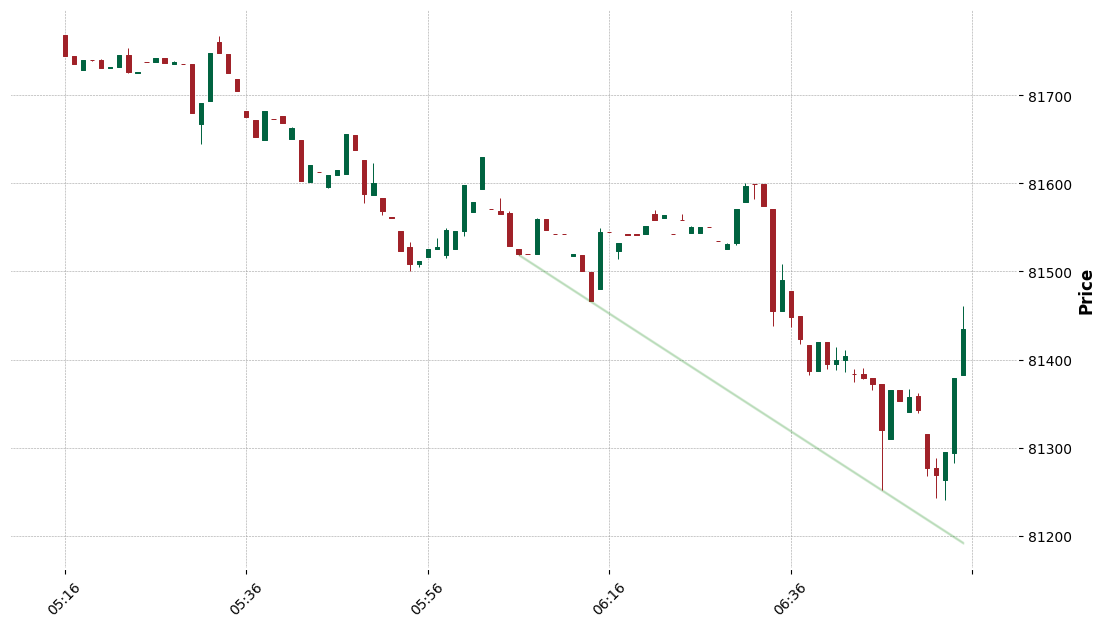

In [5]:
# Generate trendline data
support_lines = generate_trendline_data(df, minwindows[1], 'support')
resistance_lines = generate_trendline_data(df, maxwindows[1], 'resistance')

# Create line addplots
# apds = []

# for y, upper, lower, is_active in support_lines:
#     # if is_active:
#         apds.append(
#             mpf.make_addplot(y, color='green', width=0)
#         )

# for y, upper, lower, is_active in resistance_lines:
#     # if is_active:
#         apds.append(
#             mpf.make_addplot(y, color='red', width=0)
#         )

# Plot and return figure/axes
fig, axes = mpf.plot(
    df,
    type='candle',
    style='charles',
    # addplot=apds,
    returnfig=True,
    figsize=(14,8)
)

ax = axes[0]

x = np.arange(len(df))

# Add shaded regions
for upper, lower, is_active in support_lines:
    if is_active:
        ax.fill_between(
            x,
            lower,
            upper,
            color='green',
            alpha=0.15
        )

for upper, lower, is_active in resistance_lines:
    if is_active:
        ax.fill_between(
        x,
        lower,
        upper,
        color='red',
        alpha=0.15
    )

mpf.show()

## Conclusion

This notebook demonstrates how traditional trendline analysis can be
transformed into a market structure engine.

Instead of treating trendlines as static chart drawings, the system:

- detects structure,
- validates active zones,
- removes broken trendlines,
- and continuously adapts to incoming market data.

This creates a much more realistic representation of how
support and resistance behave in live markets.

---

## Future Improvements

Possible future enhancements include:

- Integrating it with websocket
- ATR-based adaptive zones
- Breakout signal generation
- Trendline ranking systems
- Multi-timeframe structure analysis
- Machine learning feature extraction
- Real-time websocket integration
- Strategy backtesting
- Market regime classification

---

## Key Takeaway

Support and resistance are not exact prices.

They are dynamic regions created by collective market behavior.

# Transition to Real-Time Engine

The logic developed in this notebook was later integrated into the
real-time websocket engine inside `main.py`.

The production engine extends this prototype by adding:

- live websocket market data,
- real-time candle construction,
- rolling market structure updates,
- active support/resistance tracking,
- and continuous chart updates.

This notebook therefore represents the research and prototyping phase
of the larger project.